## BFS

Busca em largura seguindo o Algoritmo Básico de Busca, com `abertos` como **Fila** e `fechados` para controle de estados já visitados.
Como expande os nós por níveis, garante a solução com o **menor número de movimentos**.

**Parâmetros:**
- `ORDER` — ordem de escolha das regras: `"asc"` (r1→r16) ou `"desc"` (r16→r1)
- `PRUNING` — `True`: descarta estados repetidos (BFS padrão); `False`: permite repetidos (árvore ingênua, use `MAX_DEPTH`)
- `MAX_DEPTH` — profundidade máxima de expansão quando `PRUNING = False` (ignorado se `PRUNING = True`)

Código: `algorithms/bfs.py`

In [ ]:
import sys
from pathlib import Path
import importlib

sys.path.insert(0, str(Path("algorithms").resolve()))

import bfs
from utils import INITIAL_STATE

importlib.reload(bfs)

ORDER     = "asc"   # "asc"  → r1, r2, …, r16  |  "desc" → r16, r15, …, r1
PRUNING   = True    # True  = descarta estados repetidos (BFS padrão, encontra solução)
                    # False = permite repetidos — use MAX_DEPTH para limitar a busca
MAX_DEPTH = 3       # profundidade máxima quando PRUNING = False (ignorado se PRUNING = True)

depth_arg = None if PRUNING else MAX_DEPTH

result = bfs.bfs(INITIAL_STATE, order=ORDER, pruning=PRUNING, max_depth=depth_arg)

# Desempacota resultado
if result is None:
    # Fracasso real (PRUNING=True e sem solução)
    print(f"Fracasso: abertos esvaziou sem encontrar solução "
          f"(order={ORDER!r}, pruning={PRUNING}).")
    path = applied = node_tree = trace = goal_id = None
else:
    path, applied, stats, node_tree, trace, goal_id = result
    pruning_str = "com poda" if PRUNING else f"sem poda (max_depth={depth_arg})"
    if path is not None:
        # Solução encontrada
        print(f"Sucesso! Solução com {len(applied)} movimentos "
              f"({stats['expanded']} nós expandidos, "
              f"máx. de abertos = {stats['max_open']}, "
              f"order={ORDER!r}, {pruning_str}):")
        print(" -> ".join(applied))
    else:
        # Sem poda + max_depth: árvore explorada, sem solução dentro do limite
        print(f"Árvore explorada sem poda até profundidade {depth_arg}: "
              f"{stats['expanded']} nós expandidos, "
              f"{len(node_tree)} nós na árvore "
              f"(nenhuma solução neste limite).")


Sucesso! Solução com 16 movimentos (273 nós expandidos, máx. de abertos = 29, order='asc', com poda):
r1 -> r6 -> r11 -> r10 -> r13 -> r1 -> r16 -> r4 -> r7 -> r6 -> r11 -> r10 -> r13 -> r16 -> r4 -> r7


In [6]:
# Caminho solução: nível de cada passo + estado de Abertos e Fechados
# (executado apenas quando uma solução foi encontrada)
if path is not None and goal_id is not None:
    bfs.print_solution(path, applied, node_tree, trace, goal_id, order=ORDER)
else:
    print("Nenhuma solução encontrada — verifique PRUNING e MAX_DEPTH.")



Estado inicial [Nível 0]:
bx -- by
-- -- --
px -- py

────────────────────────────────────────────────────────────
Passo 1  [Nível 1]  r1  (1 → 6)
  possibilidades: r1, r2, r5, r6, r11, r12, r15, r16

  Abertos  (ao expandir nó pai): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz]
  Fechados (ao expandir nó pai): (vazio)

  → aplica r1
-- -- by
-- -- bx
px -- py

────────────────────────────────────────────────────────────
Passo 2  [Nível 2]  r6  (3 → 8)
  possibilidades: r5, r6, r9, r11, r15, r16

  Abertos  (ao expandir nó pai): 8 nós [nível 1: 8 nós]
    • nível 1: [r1]
    • nível 1: [r2]
    • nível 1: [r5]
    • nível 1: [r6]
    • nível 1: [r11]
    • nível 1: [r12]
    • nível 1: [r15]
    • nível 1: [r16]
  Fechados (ao expandir nó pai): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz]

  → aplica r6
-- -- --
-- -- bx
px by py

────────────────────────────────────────────────────────────
Passo 3  [Nível 3]  r11  (7 → 2)
  possibilidades: r9, r11, r13, r14, r15, r16

  Abertos  (ao expan

In [7]:
# Rastreio completo da BFS (★ = nó no caminho solução)
# Ajuste MAX_ITER para limitar a saída (None = todas as iterações)
MAX_ITER = 20   # None para ver tudo
if node_tree is not None:
    bfs.print_trace(trace, node_tree, goal_id, max_iterations=MAX_ITER)
else:
    print("Sem resultados para exibir.")



══════════════════════════════════════════════════════════════════════
RASTREIO BFS — 273 iterações no total
(exibindo apenas as primeiras 20)
══════════════════════════════════════════════════════════════════════

Iteração 1 ★  |  N = nível 0  [raiz]
    Abertos (antes): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz]
    Fechados (antes): (vazio)
  Gerou 8 filho(s): [r1] (via r1), [r2] (via r2), [r5] (via r5), [r6] (via r6), [r11] (via r11), [r12] (via r12), [r15] (via r15), [r16] (via r16)
    Abertos (depois): 8 nós [nível 1: 8 nós]
    • nível 1: [r1]
    • nível 1: [r2]
    • nível 1: [r5]
    • nível 1: [r6]
    • nível 1: [r11]
    • nível 1: [r12]
    … (+2 não exibidos)
    Fechados (depois): 1 nó [nível 0: 1 nó]
    • nível 0: [raiz]

Iteração 2 ★  |  N = nível 1  [r1]
    Abertos (antes): 8 nós [nível 1: 8 nós]
    • nível 1: [r1]
    • nível 1: [r2]
    • nível 1: [r5]
    • nível 1: [r6]
    • nível 1: [r11]
    • nível 1: [r12]
    … (+2 não exibidos)
    Fechados (antes): 1

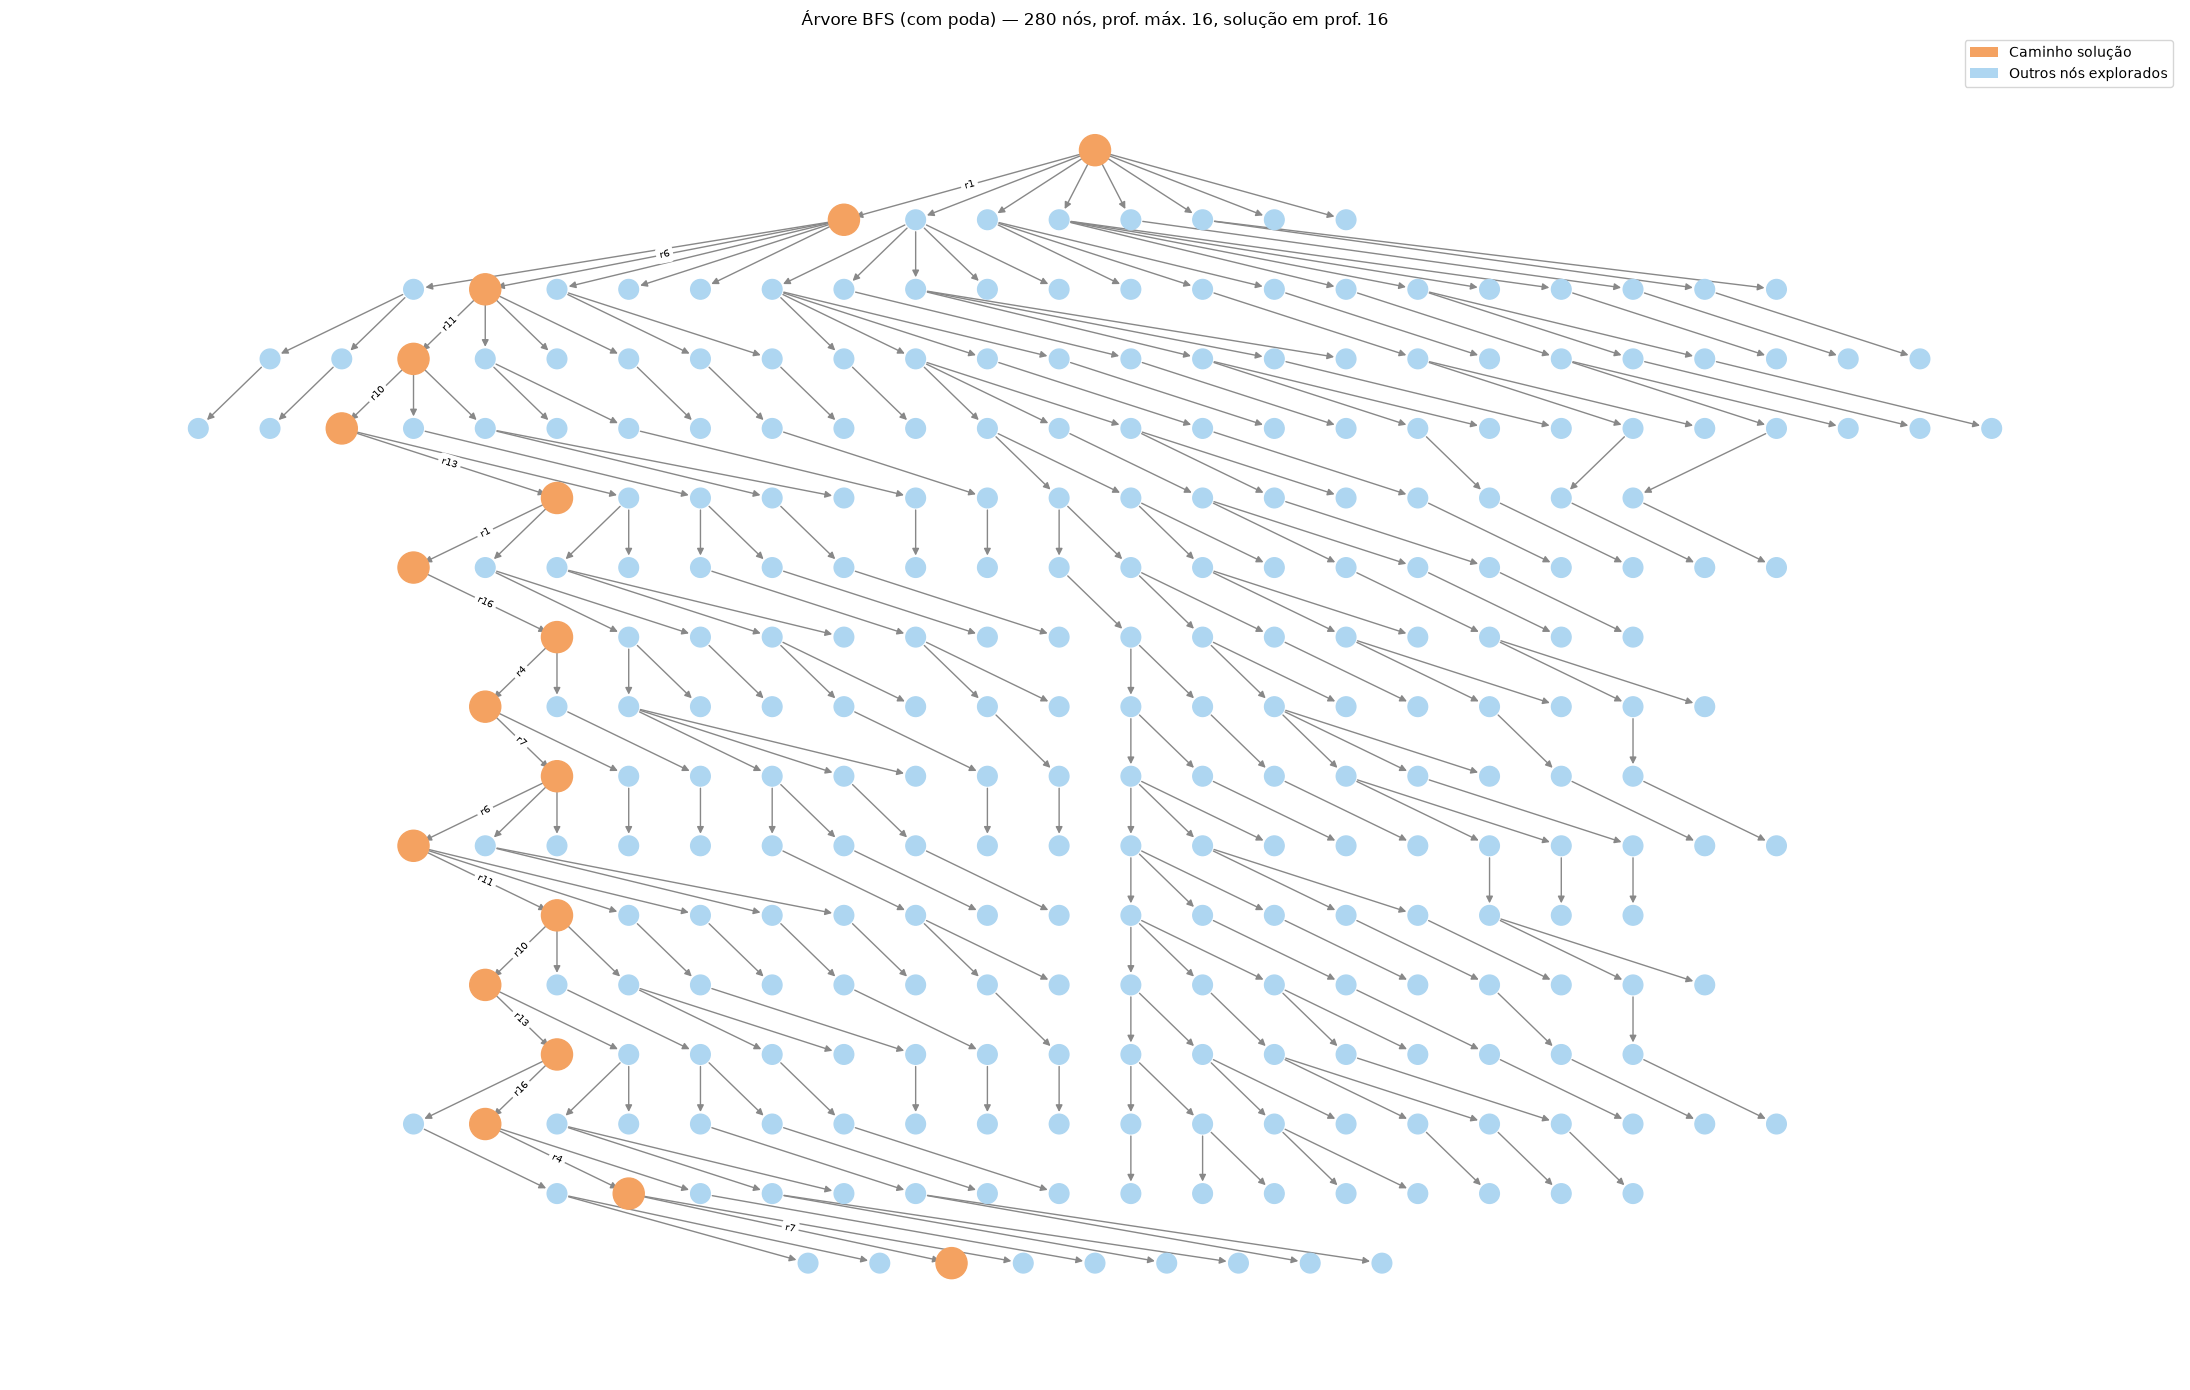

In [8]:
# Visualização da árvore de busca
# Com PRUNING=False + MAX_DEPTH pequeno a árvore é compacta mas mostra estados repetidos
if node_tree is not None:
    bfs.plot_tree(path or [], node_tree, goal_id, order=ORDER, pruning=PRUNING)
else:
    print("Sem resultados para visualizar.")
